In [36]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import config as C
from chicago_housing import constants as K
from chicago_housing.data.load import load_training_data
from chicago_housing.data import clean, distributions
from chicago_housing.features import assemble, derive
from chicago_housing.features.spatial import add_distance_to_loop
from chicago_housing.analysis import sales_descriptives as sd
from chicago_housing.viz import charts, maps

pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Basic Cleaning, Profiling and Distributions

In [38]:
# Load up training parquet and filter for Chicago, SF from 2022-2025
df = load_training_data(columns=clean.analysis_columns())   # read
df = clean.scope_filter(df)
print(f"Chicago sales dataframe has shape: {df.shape}")

scope_filter:         396,480 ->   41,762 rows
Chicago sales dataframe has shape: (41762, 46)


In [39]:
# --- Derived prep-stage variables ---------------------------------------------
# Pattern: encode each NEW variable as a function in features/derive.py (reusable
# and testable), then call it here — never as a one-off cell computation. Run
# after recode_categoricals since the flag reads the 'char_gar1_size' label.
df = derive.add_gar1_exists_flag(df)     # 1 if any garage (char_gar1_size != '0 cars')
df['char_gar1_exists'].value_counts(dropna=False)

char_gar1_exists
1       41747
<NA>       15
Name: count, dtype: Int64

In [ ]:
# Step 1 - Recode variables
df = clean.recode_categoricals(df)

recode_categoricals: 10 col(s) -> labels: ['char_air', 'char_attic_fnsh', 'char_attic_type', 'char_bsmt', 'char_bsmt_fin', 'char_gar1_att', 'char_gar1_size', 'char_heat', 'char_porch', 'char_roof_cnst']


In [45]:
# Step 2 — profile the pruned candidate columns: raw dtypes, missingness, degeneracy.
# (engineered cols aren't in the raw frame yet, so exclude K.ENGINEERED.)
candidate = (
    K.BLOCK_A_STRUCTURE
    + [c for c in K.BLOCK_B_LOCATION if c not in K.ENGINEERED]
    + K.DEMOGRAPHICS
    + ["meta_sale_price"]
)
clean.profile_columns(df, candidate)

,column,role,dtype,pct_missing,n_missing,n_unique,pct_modal,modal_value
0,acs5_median_household_renter_occupied_gross_rent,acs5,float64,0.031,1311,1103,0.007,993.000
1,acs5_median_income_household_past_year,acs5,float64,0.008,321,2087,0.004,"70,232.000"
2,acs5_median_age_total,acs5,float64,0.000,1,312,0.012,42.200
3,acs5_percent_education_bachelor,acs5,float64,0.000,1,2174,0.004,0.278
4,acs5_percent_household_owner_occupied,acs5,float64,0.000,1,2174,0.004,0.865
5,acs5_percent_income_below_poverty_level,acs5,float64,0.000,1,2175,0.004,0.099
6,char_gar1_att,char,category,0.003,134,2,0.922,No
7,char_attic_fnsh,char,category,0.002,98,3,0.807,None
8,char_porch,char,category,0.002,96,3,0.789,None
9,char_bsmt_fin,char,category,0.001,49,3,0.684,Unfinished


In [46]:
# Step 3 — fixes discovered from the profile above, recorded in constants.py:
#   CHANGE_DTYPE_FROM_FLOAT_TO_INT — counts/years stored as float -> Int64
#   DROP_REDUNDANT_COLS_WRANGLING  — redundant / superseded columns
# NOTE: 
# 1. char_attic_fnsh because ~80% values are None
# 2. Same reason for char_porch and char_attic_type
# 3. Values not meaningful in case of char_bsmt_fin, char_roof_cnst 
print("float -> Int64:", K.CHANGE_DTYPE_FROM_FLOAT_TO_INT)
print("drop redundant:", K.DROP_REDUNDANT_COLS_WRANGLING)

# Re-profile the CLEANED frame to confirm the fixes took: dtypes flip to Int64,
# and any dropped candidate shows 'COLUMN NOT FOUND'.
clean.profile_columns(df, candidate, convert_dtypes=True, drop_columns=True)

float -> Int64: ['acs5_median_household_renter_occupied_gross_rent', 'acs5_median_income_household_past_year', 'char_beds', 'char_bldg_sf', 'char_fbath', 'char_land_sf', 'char_yrblt', 'loc_access_cmap_walk_total_score', '']
drop redundant: ['char_attic_fnsh', 'char_porch', 'char_attic_type', 'char_bsmt_fin', 'char_roof_cnst']


,column,role,dtype,pct_missing,n_missing,n_unique,pct_modal,modal_value
0,acs5_median_household_renter_occupied_gross_rent,acs5,Int64,0.031,"1,311.000","1,103.000",0.007,993
1,acs5_median_income_household_past_year,acs5,Int64,0.008,321.000,"2,087.000",0.004,70232
2,acs5_median_age_total,acs5,float64,0.000,1.000,312.000,0.012,42.200
3,acs5_percent_education_bachelor,acs5,float64,0.000,1.000,"2,174.000",0.004,0.278
4,acs5_percent_household_owner_occupied,acs5,float64,0.000,1.000,"2,174.000",0.004,0.865
5,acs5_percent_income_below_poverty_level,acs5,float64,0.000,1.000,"2,175.000",0.004,0.099
6,char_gar1_att,char,category,0.003,134.000,2.000,0.922,No
7,char_air,char,category,0.000,4.000,2.000,0.627,No Central A/C
8,char_beds,char,Int64,0.000,4.000,10.000,0.492,3
9,char_bldg_sf,char,Int64,0.000,2.000,"3,194.000",0.012,1040


convert_float_to_int:  8 col(s) -> Int64: ['acs5_median_household_renter_occupied_gross_rent', 'acs5_median_income_household_past_year', 'char_beds', 'char_bldg_sf', 'char_fbath', 'char_land_sf', 'char_yrblt', 'loc_access_cmap_walk_total_score']


,column,n,mean,std,min,p01,median,p99,max,skew,kurtosis,tail_ratio,transform_hint
0,meta_sale_price,41762,"424,158.937","469,111.595","10,639.000","94,910.000","300,000.000","2,331,950.000","15,250,000.000",5.030,64.820,7.770,log candidate
1,char_land_sf,41761,"3,951.573","1,526.410",358.000,"2,666.000","3,750.000","9,148.200","39,878.000",2.690,26.220,2.440,log candidate
2,char_bldg_sf,41760,"1,448.817",667.671,400.000,892.000,"1,234.000","3,878.000","15,533.000",2.560,14.820,3.140,log candidate
3,char_fbath,41758,1.452,0.764,1.000,1.000,1.000,4.000,8.000,1.940,4.430,4.000,log candidate
4,prox_nearest_major_road_dist_ft,41761,"1,861.559","1,557.055",33.485,356.199,"1,417.930","6,982.579","7,952.769",1.390,1.700,4.920,log candidate
5,acs5_median_household_renter_occupied_gross_rent,40451,"1,373.081",406.257,99.000,977.000,"1,293.000","2,696.000","3,501.000",1.330,3.400,2.090,log candidate
6,acs5_percent_income_below_poverty_level,41761,0.150,0.110,0.000,0.038,0.119,0.486,0.756,1.210,1.360,4.080,log candidate
7,prox_nearest_cta_stop_dist_ft,41761,"8,340.200","6,449.749",60.819,"1,694.531","6,674.145","27,953.001","36,205.606",1.150,1.120,4.190,log candidate
8,acs5_median_income_household_past_year,41441,"82,983.097","39,250.706","13,438.000","39,734.000","76,500.000","209,904.000","250,001.000",1.100,1.540,2.740,log candidate
9,char_beds,41758,3.055,0.883,1.000,2.000,3.000,6.000,11.000,0.980,2.120,2.000,


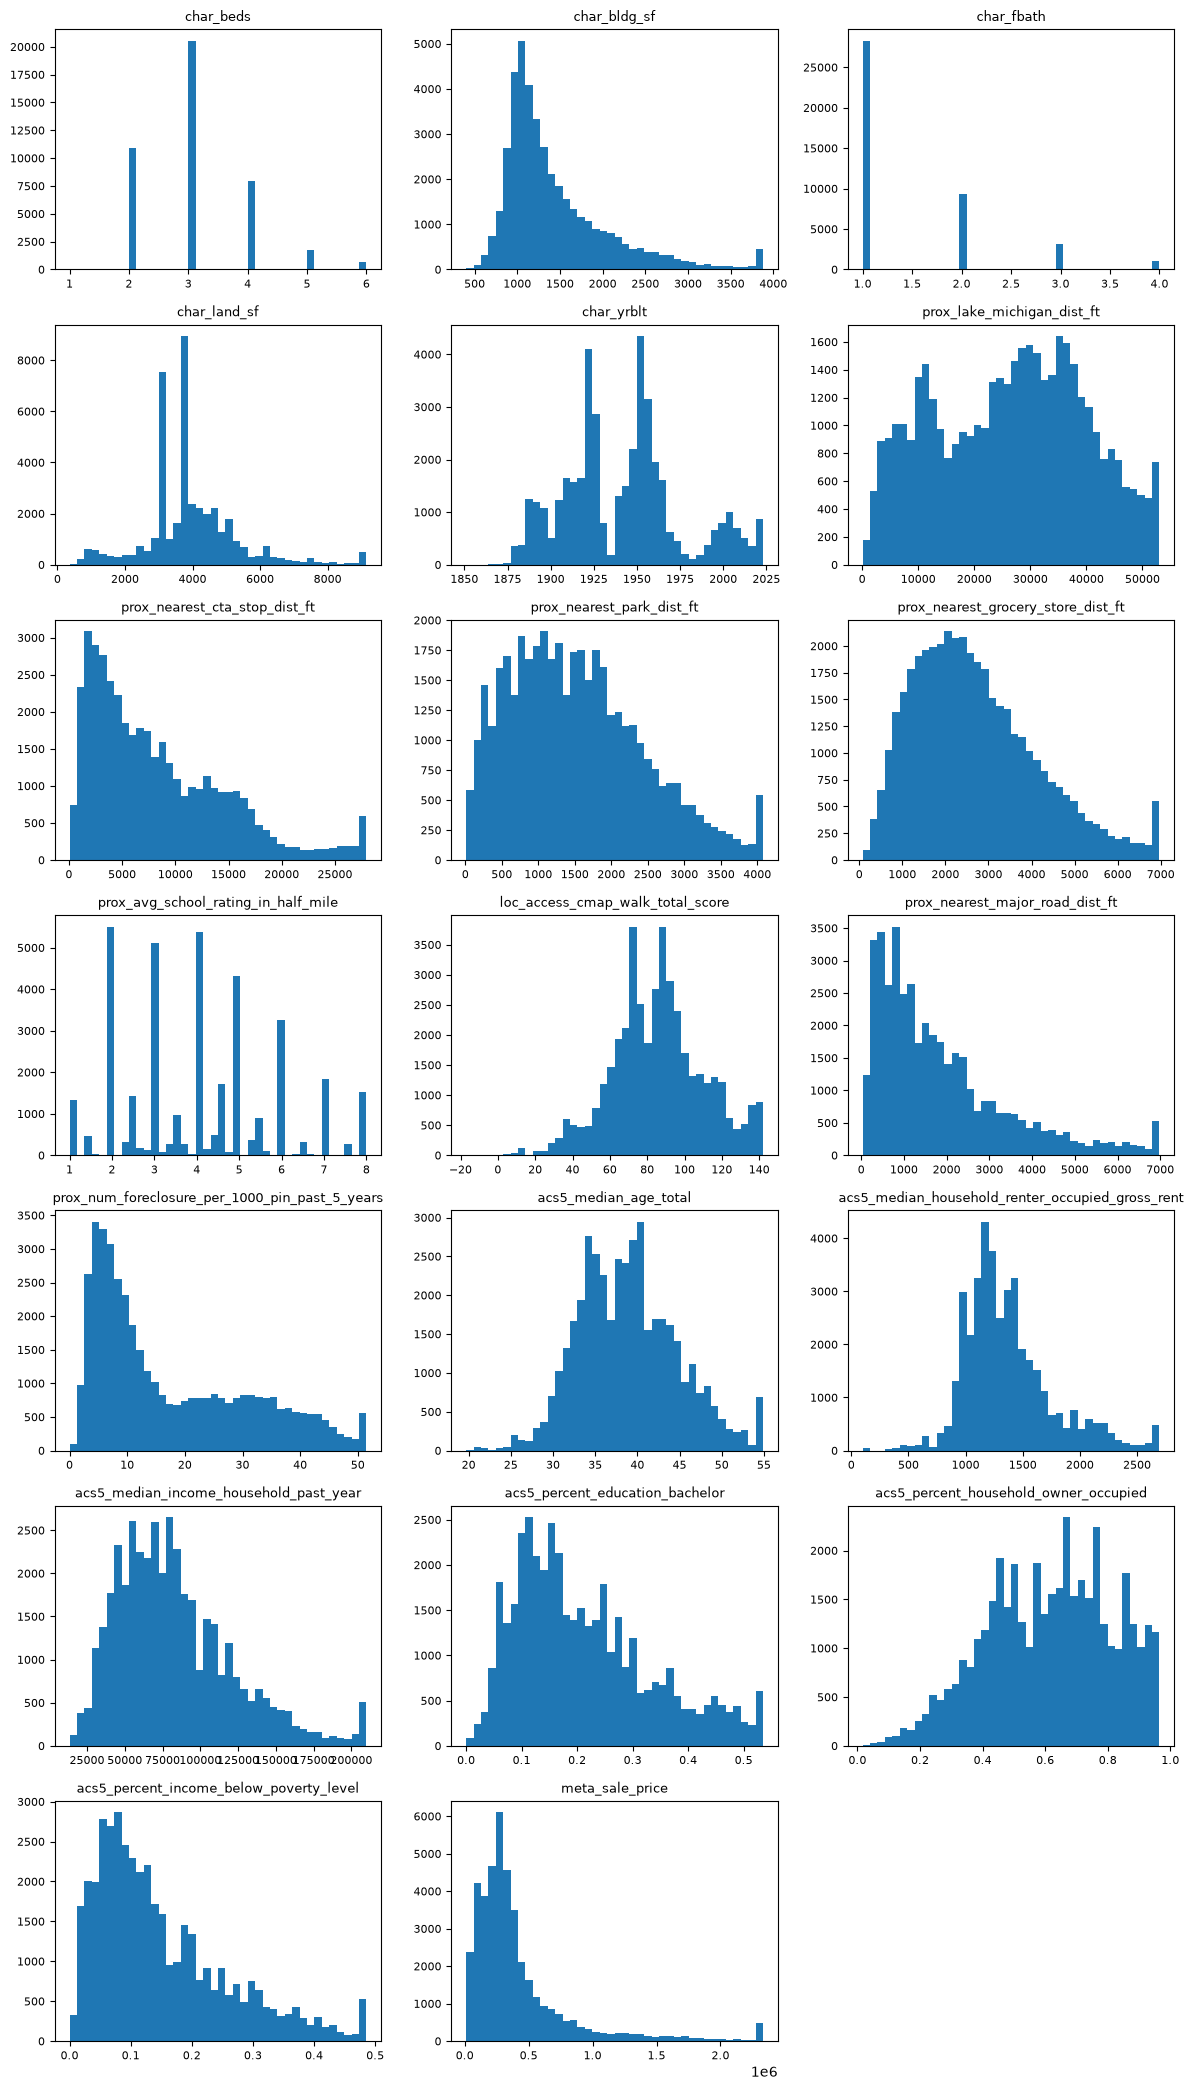

In [47]:
# Step 3 — examine distributions of the cleaned numeric columns: decide transforms,
# spot heavy tails. summarize_distributions() = the decision table (skew, tail_ratio,
# transform_hint); plot_distributions() = the shapes.
df_clean = clean.drop_redundant_columns(clean.convert_float_to_int(df), verbose=False)
summary = distributions.summarize_distributions(df_clean, candidate)
display(summary)

distributions.plot_distributions(df_clean, [c for c in candidate if c in df_clean.columns])
plt.show()

### Step 4 — Outlier / sanity analysis (report + label, no drops)
We hunt **data errors** (impossible values), *not* the genuine price-extreme tails we deliberately keep. Five lenses: (1) plausibility-bound counts, (2) price-per-sqft, (3) price-per-bedroom, (4) log-scale IQR fences, (5) boxplots + price scatter. Nothing is dropped — rows are flagged for review.

In [ ]:
# Numeric vars to scrutinize for data errors
outlier_vars = ['char_bldg_sf', 'char_land_sf', 'char_beds', 'char_fbath', 'char_yrblt', 'meta_sale_price']

# (1) logical plausibility counts — rows outside constants.SANITY_BOUNDS
display(clean.sanity_checks(df))

# (2) + (3) price ratios (a tighter lens than price alone) + their band flags
df = clean.add_price_ratios(df)     # adds price_per_sqft, price_per_bed, is_ppsf_outlier, is_ppbed_outlier
display(df[['price_per_sqft', 'price_per_bed']].describe(percentiles=[.01, .5, .99]))
print('ratio-band outliers:', int(df['is_ppsf_outlier'].sum()), '$/sqft |',
      int(df['is_ppbed_outlier'].sum()), '$/bed')

# (4) log-scale Tukey fences — an INSPECTION list (genuine tails trip it too, by design)
log_iqr = clean.flag_log_iqr(df, outlier_vars)
display(log_iqr.sum().rename('n_log_iqr_out').to_frame())

In [ ]:
# (4) boxplots  and  (5) scatter vs price — data errors sit OFF the cloud, genuine extremes ON the trend
distributions.plot_boxplots(df, outlier_vars, log=True)
distributions.plot_scatter(df, ['char_bldg_sf', 'char_land_sf', 'char_beds'], y=K.TARGET_RAW)
plt.show()

In [ ]:
# Eyeball the rows BEHIND the flags — is each a data error or a genuine extreme?
show = ['meta_pin', K.REPORT_GEO, 'meta_year', K.TARGET_RAW,
        'char_bldg_sf', 'char_beds', 'char_yrblt', 'price_per_sqft', 'price_per_bed']

print('Highest $/sqft (luxury vs price/size error):')
display(df.loc[df['is_ppsf_outlier'], show].nlargest(10, 'price_per_sqft'))

print('Lowest $/sqft (teardown / nominal-price error):')
display(df.loc[df['is_ppsf_outlier'], show].nsmallest(10, 'price_per_sqft'))